In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [7]:
# Load the data
file_path = '../data/processed/cleaned_referenda_results.csv'
data = pd.read_csv(file_path)

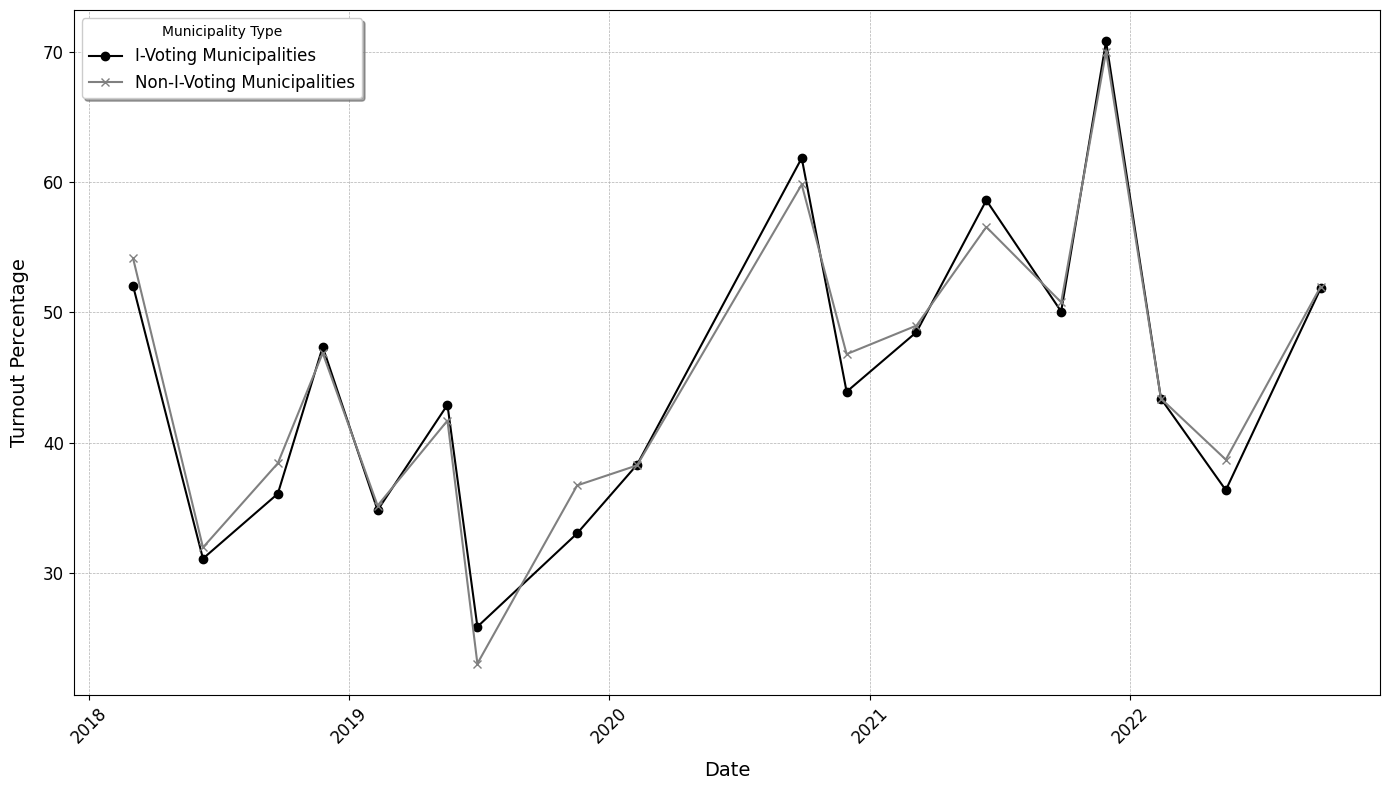

In [8]:
# Filter data for dates till 18 June 2023
data['date'] = pd.to_datetime(data['date'])
filtered_data = data[data['date'] < '2023-06-18'].copy()

# Identify non-i-voting municipalities by their codes
non_i_voting_codes = [3213, 3392, 3340, 3297, 3238]

# Add a column to identify i-voting and non-i-voting municipalities
filtered_data.loc[:, 'voting_type'] = filtered_data['entity_id'].apply(
    lambda x: 'Non-I-Voting' if x in non_i_voting_codes else 'I-Voting'
)

# Compute turnout percentage
filtered_data.loc[:, 'turnout_percentage'] = (
    (filtered_data['yeas'] + filtered_data['nays'] + filtered_data['invalid'] + filtered_data['empty']) / filtered_data['eligible_voters'] * 100
)

# Group by date and voting type and calculate mean turnout percentage
turnout_data = filtered_data.groupby(['date', 'voting_type']).turnout_percentage.mean().unstack()

# Plot the data
plt.figure(figsize=(14, 8))
plt.plot(turnout_data.index, turnout_data['I-Voting'], label='I-Voting Municipalities', color='black', linestyle='-', marker='o')
plt.plot(turnout_data.index, turnout_data['Non-I-Voting'], label='Non-I-Voting Municipalities', color='grey', linestyle='-', marker='x')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xlabel('Date', fontsize=14, labelpad=10)
plt.ylabel('Turnout Percentage', fontsize=14, labelpad=10)

plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, title='Municipality Type')
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

plt.show()


In [9]:
# Save the plot as a PNG file
plt.savefig('../results/pretrends_plot.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>